# Introduction to MLflow
### Author: Kirill Zakharov
April 2025

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, roc_auc_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import mlflow
from mlflow.models import infer_signature

### Import Data

In [3]:
data = pd.read_csv('Data/air_train.csv')

In [4]:
data.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [5]:
data['satisfaction'].value_counts()

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

In [6]:
object_data = data.dtypes.index[np.where(data.dtypes == 'object')[0]].values
data = pd.concat([data.drop(object_data[:-1], axis=1), pd.get_dummies(data[object_data[:-1]]).astype(int)], axis=1)
data = data.drop(['Unnamed: 0', 'id'], axis=1)

In [7]:
data['satisfaction'] = data['satisfaction'].replace({'neutral or dissatisfied': 0, 'satisfied': 1}).infer_objects(copy=False)
data = data.dropna()

/var/folders/31/d4jscthx2pn2pzww22f7p67r0000gn/T/ipykernel_41160/2234984959.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['satisfaction'] = data['satisfaction'].replace({'neutral or dissatisfied': 0, 'satisfied': 1}).infer_objects(copy=False)


In [8]:
data.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,satisfaction,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,13,460,3,4,3,1,5,3,5,5,...,0,0,1,1,0,0,1,0,0,1
1,25,235,3,2,3,3,1,3,1,1,...,0,0,1,0,1,1,0,1,0,0
2,26,1142,2,2,2,2,5,5,5,5,...,1,1,0,1,0,1,0,1,0,0
3,25,562,2,5,5,5,2,2,2,2,...,0,1,0,1,0,1,0,1,0,0
4,61,214,3,3,3,3,4,5,5,3,...,1,0,1,1,0,1,0,1,0,0


### Split data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(data.drop('satisfaction', axis=1).values, data['satisfaction'].values, test_size=0.3)

### MLflow tracking for classical ML algorithms

In [25]:
params = {
    "max_depth": 1,
    "n_estimators": 50,
    "random_state": 22,
    "learning_rate": 1e-2
}

In [26]:
xgb = XGBClassifier(**params)
xgb.fit(X_train, y_train)

prediction = xgb.predict(X_test)

In [ ]:
# Uncomment for Logistic Regression

# params = {
#     "random_state": 22,
#     "max_iter": 100
# }

# lr = LogisticRegression(**params)
# lr.fit(X_train, y_train)

# prediction = lr.predict(X_test)

In [45]:
rocauc = roc_auc_score(y_test, prediction)
rocauc

0.8170980252191417

In [46]:
def draw_confusion_matrix(prediction):
    cm = confusion_matrix(y_test, prediction, normalize='all')
    fig, axs = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(cm, display_labels = [0, 1]).plot(cmap='viridis', ax=axs)
    plt.tight_layout()
    plt.close(fig)
    return fig

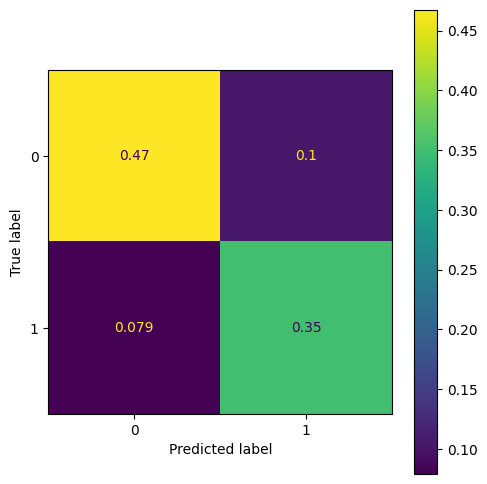

In [47]:
fig1 = draw_confusion_matrix(prediction)
fig1

In [ ]:
# Start server with the command
# mlflow server --host 127.0.0.1 --port 8080

mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")
mlflow.set_experiment("Classic_ML")

In [ ]:
with mlflow.start_run(description='Experiments with *classical* ML algorithms') as run:
    mlflow.log_params(params)
    mlflow.log_metric("roc_auc", rocauc)
    mlflow.log_figure(fig1, 'Confusion_matrix.png')
    
    
    mlflow.set_tag("Model type", "XGBoost")
    signature = infer_signature(X_train, xgb.predict(X_train))


    model_info = mlflow.xgboost.log_model(
        xgb_model=xgb,
        artifact_path="xgb_airplane_data",
        signature=signature,
        input_example=X_train,
        # registered_model_name="XGB_v0",
    )
    
    # mlflow.set_tag("Model type", "LogReg")
    # signature = infer_signature(X_train, lr.predict(X_train))
    
    # model_info = mlflow.sklearn.log_model(
    #     lr,
    #     artifact_path="log_reg_airplane_data",
    #     signature=signature,
    #     input_example=X_train,
    #     # registered_model_name="LogR_v0",
    # )

### MLflow tracking for neural networks with Pytorch

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchsummary import summary

from tqdm import tqdm

In [ ]:
class Classifier(nn.Module):
    def __init__(self, **kwargs):
        super(Classifier, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(kwargs.get('in_dim'), 2**7),
            nn.SiLU(),
            nn.Linear(2**7, 2**7),
            nn.SiLU(),
            nn.Linear(2**7, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        out = self.model(x)
        
        return out

In [75]:
NUM_EPOCHS = 100
BATCH_SIZE = 64
torch.manual_seed(55555)

In [76]:
X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor = \
    torch.tensor(X_train.astype('float32')),\
    torch.tensor(X_test.astype('float32')),\
    torch.tensor(y_train.astype('float32').reshape(-1, 1)),\
    torch.tensor(y_test.astype('float32').reshape(-1, 1))
    
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [77]:
def train(num_epochs):
    model = Classifier(in_dim=27)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=2e-4)

    epochs = tqdm(range(num_epochs))
    criterion = nn.BCELoss()
    
    model.train()

    for i in epochs:
        epoch_loss = 0
        for data, target in train_loader:
            
            output = model(data)
            loss = criterion(output, target)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
            optimizer.step()
            
            epoch_loss += loss.item()
        
        scheduler.step()
        
        epoch_loss = epoch_loss/data.size(0)
            
        if i % 10 == 0:
            epochs.set_description(f'Loss: {epoch_loss}')
            mlflow.log_metric("Loss", f"{epoch_loss:3f}")
            
    return model

In [ ]:
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")
mlflow.set_experiment("NeuralNetworks")

In [ ]:
with mlflow.start_run(description='Experiments with DL algorithms', tags={'version': 'v0'}, run_name='NN_64'):
    mlflow.set_tag("Model type", "Neural Network")
    
    params = {
        "epochs": NUM_EPOCHS,
        "learning_rate_start": 1e-3,
        "batch_size": BATCH_SIZE,
        "loss_function": nn.BCELoss(),
        "optimizer": "AdamW",
        "scheduler": 'optim.lr_scheduler.CosineAnnealingLR()'
    }
    
    mlflow.log_params(params)

    model_NN = train(NUM_EPOCHS)
    
    
    with open("model_summary.txt", "w") as file:
        file.write(str(summary(model_NN, input_size=(BATCH_SIZE, X_train_tensor.size(1)))))
        
    mlflow.log_artifact("model_summary.txt")
    
    
    signature = infer_signature(X_train, model_NN(X_train_tensor).detach().cpu().numpy())
    mlflow.pytorch.log_model(model_NN, "model_NN", signature=signature)
    
    
    model_NN.eval()
    with torch.no_grad():
        prediction_NN = model_NN(X_test_tensor).detach().cpu().numpy().T[0]
        prediction_NN = np.array([1 if i > 0.5 else 0 for i in prediction_NN])
    
    rocauc = roc_auc_score(y_test, prediction_NN)
    mlflow.log_metric("roc_auc", rocauc)
    
    fig1 = draw_confusion_matrix(prediction_NN)
    mlflow.log_figure(fig1, 'Confusion_matrix.png')

### Load the model

In [84]:
# model_name = "xgboost"
# model_version = "latest"

# # Load the model from the Model Registry
# model_uri = f"models:/{model_name}/{model_version}"

In [ ]:
# mlflow.active_run().info.run_id
# run.info.run_id
# model_uri = f"runs:/{run.info.run_id}/models"
# loaded_model = mlflow.pyfunc.load_model(model_uri)

# predictions = loaded_model.predict(X_test)

# result = pd.DataFrame(X_test, columns=data.drop('satisfaction', axis=1).columns)
# result["actual_class"] = y_test
# result["predicted_class"] = predictions

# result[:4]